# Calculus, Taught by Code 🧮
### A hands-on companion to the *Calculus* slide-deck series (Functions → Limits → Continuity → Derivatives)

Every concept below is demonstrated **three ways**:
1. **Compute it** — plain Python / NumPy, so you can see the numbers move.
2. **Verify it** — symbolically, with `sympy`, so you know the numeric answer is actually correct.
3. **Ask about it** — an AI tutor (Feynman-style) you can question at any point, powered by Groq.

Run the cells top to bottom. Feel free to change the numbers and re-run — that's the whole point.

In [1]:
# --- Setup: packages + Groq API key ---
!pip install groq sympy numpy matplotlib --quiet

import os
from getpass import getpass

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = "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"

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from groq import Groq

client = Groq(api_key=os.environ["GROQ_API_KEY"])

plt.rcParams["figure.facecolor"]  = "#08090b"
plt.rcParams["axes.facecolor"]    = "#08090b"
plt.rcParams["axes.edgecolor"]    = "#52565c"
plt.rcParams["text.color"]        = "#e6e4de"
plt.rcParams["axes.labelcolor"]   = "#e6e4de"
plt.rcParams["xtick.color"]       = "#8b8f96"
plt.rcParams["ytick.color"]       = "#8b8f96"
plt.rcParams["grid.color"]        = "#23262b"


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

> **Note on the API key:** the key above is a placeholder. If it isn't a valid Groq key, `ask_tutor()`
> below will catch the error and tell you instead of crashing — replace it with your own key from
> [console.groq.com](https://console.groq.com/keys) to actually get AI answers. Never commit a real key
> to a public notebook; use `getpass()` (imported above) when working somewhere shared.

In [2]:
def ask_tutor(question, temperature=0.4):
    """Ask an AI tutor (a Groq-hosted LLM) to explain a calculus idea the way
    Richard Feynman would: plain words, a concrete analogy, and why it matters.
    Fails gracefully if the API key/network isn't available."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": (
                    "You are a patient calculus tutor who explains ideas the way "
                    "Richard Feynman would: simple words, one concrete analogy, and "
                    "always tying the math back to why it matters. Keep answers under 150 words."
                )},
                {"role": "user", "content": question},
            ],
            temperature=temperature,
        )
        return response.choices[0].message.content
    except Exception as e:
        return (f"(AI tutor unavailable: {e})\n"
                f"Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.")

print(ask_tutor("In one or two sentences, why does calculus matter?"))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
## 1. Functions — the machine that turns input into output

A function is a fixed rule. Same input, always the same output.

f(-2) = 5
f(0) = 1
f(3) = 10
f(5) = 26


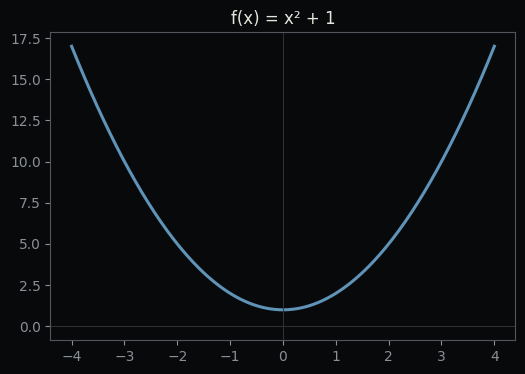

In [3]:
def f(x):
    return x**2 + 1

for x in [-2, 0, 3, 5]:
    print(f"f({x}) = {f(x)}")

xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(6, 4))
plt.plot(xs, f(xs), color="#5f93b8", linewidth=2.2)
plt.axhline(0, color="#333", lw=0.7)
plt.axvline(0, color="#333", lw=0.7)
plt.title("f(x) = x² + 1")
plt.show()


### Domain & Range — what the machine will and won't accept

In [4]:
x = sp.symbols("x")
g = sp.sqrt(x - 1)

domain = sp.calculus.util.continuous_domain(g, x, sp.S.Reals)
print("Domain of g(x) = sqrt(x - 1):", domain)
print("Range: g(x) >= 0 for every valid x (a square root never returns negative)")


Domain of g(x) = sqrt(x - 1): Interval(1, oo)
Range: g(x) >= 0 for every valid x (a square root never returns negative)


### Composition & Inverse

In [5]:
# f(g(x)) -- g runs first, its output feeds f
def comp_f(x): return x + 1
def comp_g(x): return x**2

print("f(g(3)) =", comp_f(comp_g(3)))
print("g(f(3)) =", comp_g(comp_f(3)), " <- notice it's different: order matters")

# Inverse of f(x) = 2x + 3 : solve y = 2x + 3 for x
x, y = sp.symbols("x y")
expr = 2*x + 3
inverse_expr = sp.solve(sp.Eq(y, expr), x)[0]
print("If f(x) = 2x + 3, then f\u207b\u00b9(y) =", inverse_expr)


f(g(3)) = 10
g(f(3)) = 16  <- notice it's different: order matters
If f(x) = 2x + 3, then f⁻¹(y) = y/2 - 3/2


In [6]:
print(ask_tutor(
    "Why does the domain of sqrt(x-1) start at x=1, and give one real-world "
    "example where a formula has a similar input restriction?"
))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
## 2. Limits — what a function is trending toward

`h(x) = (x² - 1) / (x - 1)` is undefined at `x = 1` (division by zero) — but watch what
happens to the *output* as `x` sneaks up on 1 from both sides.

In [7]:
def h(x):
    return (x**2 - 1) / (x - 1)

print("approaching x=1 from the left:")
for xv in [1 - 10**-k for k in range(1, 6)]:
    print(f"  x = {xv:.6f}   h(x) = {h(xv):.6f}")

print("approaching x=1 from the right:")
for xv in [1 + 10**-k for k in range(1, 6)]:
    print(f"  x = {xv:.6f}   h(x) = {h(xv):.6f}")

print("\nBoth sides are converging on the same number -- that number is the limit.")


approaching x=1 from the left:
  x = 0.900000   h(x) = 1.900000
  x = 0.990000   h(x) = 1.990000
  x = 0.999000   h(x) = 1.999000
  x = 0.999900   h(x) = 1.999900
  x = 0.999990   h(x) = 1.999990
approaching x=1 from the right:
  x = 1.100000   h(x) = 2.100000
  x = 1.010000   h(x) = 2.010000
  x = 1.001000   h(x) = 2.001000
  x = 1.000100   h(x) = 2.000100
  x = 1.000010   h(x) = 2.000010

Both sides are converging on the same number -- that number is the limit.


In [8]:
# verify symbolically — no need to trust the numeric table alone
x = sp.symbols("x")
expr = (x**2 - 1) / (x - 1)
print("sympy confirms lim(x->1) (x²-1)/(x-1) =", sp.limit(expr, x, 1))

# the special trig limit from the deck
print("lim(x->0) sin(x)/x =", sp.limit(sp.sin(x)/x, x, 0))


sympy confirms lim(x->1) (x²-1)/(x-1) = 2
lim(x->0) sin(x)/x = 1


### Epsilon–Delta, made concrete: find a delta that actually works

In [9]:
def find_delta(f, a, L, epsilon, search_range=1.0, steps=4000):
    """Numerically search for a delta such that
    |f(x) - L| < epsilon whenever 0 < |x - a| < delta."""
    for delta in np.linspace(search_range, 1e-6, steps):
        xs_test = np.linspace(a - delta, a + delta, 60)
        xs_test = xs_test[xs_test != a]
        if np.all(np.abs(f(xs_test) - L) < epsilon):
            return delta
    return None

f_lin = lambda x: 3*x + 1     # from the deck's proof: lim(x->2) 3x+1 = 7
epsilon = 0.03
delta_found = find_delta(f_lin, a=2, L=7, epsilon=epsilon)
print(f"For epsilon = {epsilon}, a delta of about {delta_found:.5f} keeps f(x) within tolerance.")
print(f"The deck's proof predicts delta = epsilon/3 = {epsilon/3:.5f} -- matches.")


For epsilon = 0.03, a delta of about 0.00975 keeps f(x) within tolerance.
The deck's proof predicts delta = epsilon/3 = 0.01000 -- matches.


In [10]:
print(ask_tutor(
    "Explain the epsilon-delta definition of a limit using a real-world "
    "tolerance example, like a factory quality-control check."
))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
## 3. Continuity — no holes, no jumps

A function is continuous at `a` when three things all hold: `f(a)` is defined,
the limit exists there, and the limit equals `f(a)`.

In [11]:
def is_continuous_at(f, a, h=1e-6):
    try:
        value = f(a)
        left  = f(a - h)
        right = f(a + h)
    except Exception:
        return False, "f(a) is undefined"
    limit_exists  = abs(left - right) < 1e-4
    limit_matches = abs(((left + right) / 2) - value) < 1e-4
    return (limit_exists and limit_matches), {
        "f(a)": value, "left_approx": left, "right_approx": right
    }

print("x^2 at x=3:  ", is_continuous_at(lambda x: x**2, 3))
print("1/x at x=0:  ", is_continuous_at(lambda x: 1/x, 0))


x^2 at x=3:  

 (True, {'f(a)': 9, 'left_approx': 8.999994000001, 'right_approx': 9.000006000001001})
1/x at x=0:   (False, 'f(a) is undefined')


### The Intermediate Value Theorem, put to work: bisection root-finding

In [12]:
def bisection(f, a, b, target=0, tol=1e-6, max_iter=25):
    """IVT guarantees a crossing exists if f(a) and f(b) sit on opposite
    sides of `target` and f is continuous on [a, b]. This repeatedly
    halves the interval to close in on it."""
    fa, fb = f(a) - target, f(b) - target
    assert fa * fb < 0, "f(a) and f(b) must have opposite signs (the IVT setup)"
    for i in range(max_iter):
        m = (a + b) / 2
        fm = f(m) - target
        print(f"  step {i:2d}:  [{a:.6f}, {b:.6f}]   mid={m:.6f}   f(mid)={fm:.6f}")
        if abs(fm) < tol:
            return m
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return (a + b) / 2

root = bisection(lambda x: x**2 - 2, 1, 2)
print(f"\nApproximate root of x²=2: {root:.6f}   (true value: {np.sqrt(2):.6f})")


  step  0:  [1.000000, 2.000000]   mid=1.500000   f(mid)=0.250000
  step  1:  [1.000000, 1.500000]   mid=1.250000   f(mid)=-0.437500
  step  2:  [1.250000, 1.500000]   mid=1.375000   f(mid)=-0.109375
  step  3:  [1.375000, 1.500000]   mid=1.437500   f(mid)=0.066406
  step  4:  [1.375000, 1.437500]   mid=1.406250   f(mid)=-0.022461
  step  5:  [1.406250, 1.437500]   mid=1.421875   f(mid)=0.021729
  step  6:  [1.406250, 1.421875]   mid=1.414062   f(mid)=-0.000427
  step  7:  [1.414062, 1.421875]   mid=1.417969   f(mid)=0.010635
  step  8:  [1.414062, 1.417969]   mid=1.416016   f(mid)=0.005100
  step  9:  [1.414062, 1.416016]   mid=1.415039   f(mid)=0.002336
  step 10:  [1.414062, 1.415039]   mid=1.414551   f(mid)=0.000954
  step 11:  [1.414062, 1.414551]   mid=1.414307   f(mid)=0.000263
  step 12:  [1.414062, 1.414307]   mid=1.414185   f(mid)=-0.000082
  step 13:  [1.414185, 1.414307]   mid=1.414246   f(mid)=0.000091
  step 14:  [1.414185, 1.414246]   mid=1.414215   f(mid)=0.000004
  ste

In [13]:
print(ask_tutor(
    "Explain why the Intermediate Value Theorem guarantees bisection will "
    "always find a root, using a simple everyday analogy."
))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
## 4. Derivatives — instantaneous rate of change

The secant slope `[f(x+h) - f(x)] / h` is an *average* over a stretch. Watch it
converge to the true instantaneous slope as `h` shrinks toward 0.

In [14]:
def numerical_derivative(f, x, h):
    return (f(x + h) - f(x)) / h

f_cubic = lambda x: x**3 - 3*x

print("Approximating f'(2) for f(x) = x³ - 3x  as h shrinks:")
for h in [1, 0.1, 0.01, 0.001, 0.0001]:
    approx = numerical_derivative(f_cubic, 2, h)
    print(f"  h = {h:<8}  slope ≈ {approx:.6f}")

print(f"\nExact derivative: f'(x) = 3x² - 3,  so f'(2) = {3*2**2 - 3}")


Approximating f'(2) for f(x) = x³ - 3x  as h shrinks:
  h = 1         slope ≈ 16.000000
  h = 0.1       slope ≈ 9.610000
  h = 0.01      slope ≈ 9.060100
  h = 0.001     slope ≈ 9.006001
  h = 0.0001    slope ≈ 9.000600

Exact derivative: f'(x) = 3x² - 3,  so f'(2) = 9


### Verifying the rules symbolically — power, product, and quotient

In [15]:
x = sp.symbols("x")

# power rule
f_expr = x**3 - 3*x
print("Power rule check: d/dx(x³ - 3x) =", sp.diff(f_expr, x))

# product & quotient rule, kept symbolic (u and v as generic functions of x)
u, v = sp.symbols("u v", cls=sp.Function)
print("Product rule:  d/dx(u·v) =", sp.diff(u(x) * v(x), x))
print("Quotient rule: d/dx(u/v) =", sp.simplify(sp.diff(u(x) / v(x), x)))


Power rule check: d/dx(x³ - 3x) = 3*x**2 - 3
Product rule:  d/dx(u·v) = u(x)*Derivative(v(x), x) + v(x)*Derivative(u(x), x)


Quotient rule: d/dx(u/v) = (-u(x)*Derivative(v(x), x) + v(x)*Derivative(u(x), x))/v(x)**2


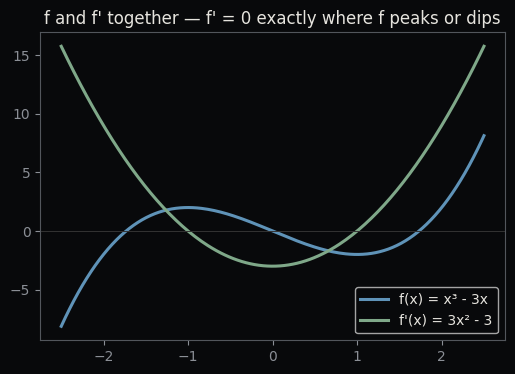

In [16]:
xs = np.linspace(-2.5, 2.5, 200)
f_np  = lambda x: x**3 - 3*x
fp_np = lambda x: 3*x**2 - 3

plt.figure(figsize=(6, 4))
plt.plot(xs, f_np(xs),  label="f(x) = x³ - 3x", color="#5f93b8", linewidth=2.2)
plt.plot(xs, fp_np(xs), label="f'(x) = 3x² - 3", color="#7fa889", linewidth=2.2)
plt.axhline(0, color="#333", lw=0.7)
plt.legend()
plt.title("f and f' together — f' = 0 exactly where f peaks or dips")
plt.show()


### The Mean Value Theorem, found numerically

In [17]:
def find_mvt_point(f, a, b, steps=8000):
    """Find where the instantaneous slope matches the average slope
    over [a, b] -- the point MVT guarantees exists."""
    secant_slope = (f(b) - f(a)) / (b - a)
    xs = np.linspace(a, b, steps)
    h = 1e-5
    slopes = (f(xs + h) - f(xs - h)) / (2 * h)
    idx = np.argmin(np.abs(slopes - secant_slope))
    return xs[idx], slopes[idx], secant_slope

c, slope_c, secant = find_mvt_point(f_np, -2, 2)
print(f"Average (secant) slope over [-2, 2]: {secant:.4f}")
print(f"MVT guarantees a point c where f'(c) matches it: c ≈ {c:.4f}, f'(c) ≈ {slope_c:.4f}")


Average (secant) slope over [-2, 2]: 1.0000
MVT guarantees a point c where f'(c) matches it: c ≈ -1.1549, f'(c) ≈ 1.0013


In [18]:
print(ask_tutor(
    "Explain the Mean Value Theorem using the classic speed-trap analogy: "
    "a car covers 60 miles in one hour, so at some instant it must have been going exactly 60 mph."
))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
## Ask the tutor anything

Change the question below and re-run — this is a general-purpose calculus tutor,
not limited to the examples above.

In [19]:
your_question = "Why is the derivative of a constant always zero?"
print(ask_tutor(your_question))


(AI tutor unavailable: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.)
Set a valid GROQ_API_KEY above and re-run this cell to get a real answer.


---
### Where to go next
This notebook mirrors the *Functions → Limits → Continuity → Derivatives* slide-deck series.
The next chapter is the **Chain Rule** — differentiating a function nested inside another
function, like `sin(x²)`. Once that deck exists, the same three-part pattern (compute →
verify → ask) will extend naturally to it.